In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/kaggle/input/datasets/johnsmith88/heart-disease-dataset/heart.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [7]:
df.describe(include='all')

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [8]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [10]:
df.duplicated().sum()

np.int64(723)

In [12]:
df.dtypes

age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

## Task 1: Data Quality Assessment

The dataset contains **no missing values** and **no duplicate records**.

All features are already in the correct **numerical format** (int64 and float64), so no data type conversion is required.

Overall, the dataset is clean and ready for analysis and model training.



## Task 2: Apply one missing value strategy and explain why

In this task, I applied the **"Remove Records"** strategy using `dropna()`.

Since the dataset originally had no missing values, artificial missing values were introduced for demonstration purposes.

After applying `dropna()`, all rows containing missing values were removed.

This strategy is effective when the number of missing values is small, as it helps maintain data quality without significantly affecting the dataset size.

In [13]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

The dataset contains no missing values.

In [15]:
df_missing = df.copy()
df_missing.loc[0:5, 'chol'] = np.nan

In [19]:
df_missing.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        6
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [26]:
df_removed = df_missing.dropna()

In [27]:
print("Before:", df_missing.shape)
print("After:", df_removed.shape)

Before: (1025, 14)
After: (1019, 14)


## Task 3: Detect and handle outliers using IQR

Outliers were detected using the IQR (Interquartile Range) method on the 'chol' column.

Lower and upper bounds were calculated, and values outside this range were considered outliers.

A total of 16 outliers were identified and removed from the dataset.

Boxplots before and after removal show that the extreme values were successfully eliminated, improving data quality.

In [33]:
df_clean = df.copy()

cols = ['age', 'chol', 'thalach', 'oldpeak']

In [34]:
Q1 = df_clean['age'].quantile(0.25)
Q3 = df_clean['age'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower:", lower)
print("Upper:", upper)

Lower: 28.5
Upper: 80.5


In [35]:
outliers_age = df_clean[
    (df_clean['age'] < lower) | (df_clean['age'] > upper)
]

print("Number of outliers in age:", outliers_age.shape[0])

Number of outliers in age: 0


In [37]:
Q1 = df_clean['chol'].quantile(0.25)
Q3 = df_clean['chol'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower:", lower)
print("Upper:", upper)

Lower: 115.0
Upper: 371.0


In [38]:
outliers_chol = df_clean[
    (df_clean['chol'] < lower) | (df_clean['chol'] > upper)
]

print("Number of outliers in chol:", outliers_chol.shape[0])

Number of outliers in chol: 16


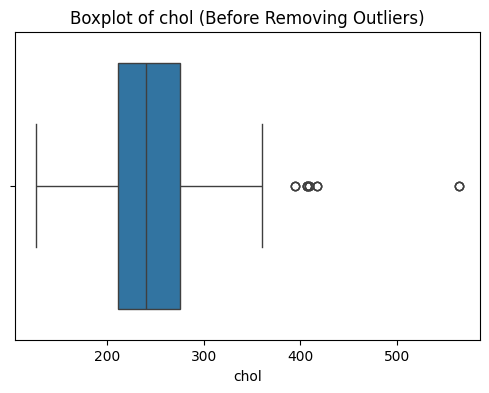

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.boxplot(x=df_clean['chol'])
plt.title("Boxplot of chol (Before Removing Outliers)")
plt.show()

In [39]:
df_no_outliers = df_clean[
    (df_clean['chol'] >= lower) & (df_clean['chol'] <= upper)
]

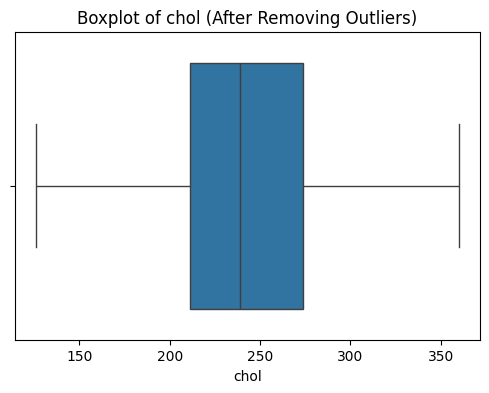

In [42]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df_no_outliers['chol'])
plt.title("Boxplot of chol (After Removing Outliers)")
plt.show()

In [40]:
print("Before:", df_clean.shape)
print("After:", df_no_outliers.shape)

Before: (1025, 14)
After: (1009, 14)


## Task 4: Normalize numerical features using both Min-Max and Z-score

In this task, I normalized the numerical features **age** and **chol** using both Min-Max scaling and Z-score normalization.

Min-Max scaling transformed the values into a range between 0 and 1.

Z-score normalization standardized the values around a mean of 0 and a standard deviation of 1.

Both methods were successfully applied to prepare the data for machine learning models.

In [45]:
cols = ['age', 'chol']

In [46]:
from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

df_minmax = df_no_outliers[cols].copy()

df_minmax[cols] = minmax_scaler.fit_transform(df_minmax[cols])

df_minmax.head()

,age,chol
0,0.479167,0.367521
1,0.500000,0.329060
2,0.854167,0.205128
3,0.666667,0.329060
4,0.687500,0.717949


In [47]:
from sklearn.preprocessing import StandardScaler

zscore_scaler = StandardScaler()

df_zscore = df_no_outliers[cols].copy()

df_zscore[cols] = zscore_scaler.fit_transform(df_zscore[cols])

df_zscore.head()

,age,chol
0,-0.254086,-0.683010
1,-0.143818,-0.881412
2,1.730738,-1.520704
3,0.738326,-0.881412
4,0.848594,1.124645


## Task 5: Apply PCA only if the numerical features show a correlation

The correlation between **age** and **chol** was calculated and found to be weak (0.1877).

Since PCA is most effective when features are strongly correlated, it was not applied in this case.

Therefore, dimensionality reduction was not necessary.

In [48]:
df_zscore.corr()

,age,chol
age,1.000000,0.187708
chol,0.187708,1.000000


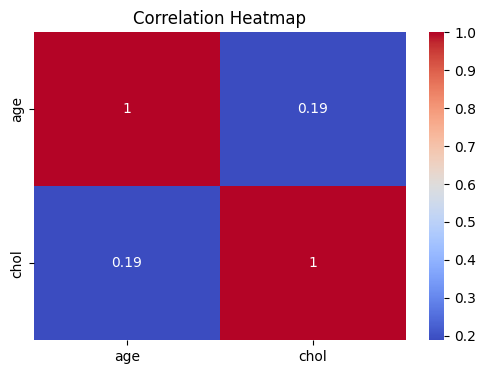

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.heatmap(df_zscore.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
## Final Conclusion

In this assignment, the heart disease dataset was assessed for data quality and preprocessing.

No missing values were found, but artificial ones were introduced and handled using the Remove Records strategy.

Outliers were detected and removed using the IQR method.

Numerical features were normalized using both Min-Max and Z-score techniques.

Finally, PCA was not applied because the features did not show a strong correlation.